In [1]:
from mne.datasets import eegbci
from mne.io import read_raw_edf, concatenate_raws

subject = 1
runs = [4, 8, 12]   # left vs right hand motor imagery

fnames = eegbci.load_data(subject, runs)
raws = [read_raw_edf(f, preload=True) for f in fnames]
raw = concatenate_raws(raws)

print(raw)

Matplotlib is building the font cache; this may take a moment.


Using default location ~/mne_data for EEGBCI...
Creating /Users/lucylu/mne_data


/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Attempting to create new mne-python configuration file:
/Users/lucylu/.mne/mne-python.json
Download complete in 06m50s (7.4 MB)
Extracting EDF parameters from /Users/lucylu/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/lucylu/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/lucylu/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MB, data loaded>


In [2]:
print("Sampling rate:", raw.info['sfreq'], "Hz")
print("Number of channels:", len(raw.ch_names))
print("Channel names:", raw.ch_names)
print("Annotation types present:", set(raw.annotations.description))

Sampling rate: 160.0 Hz
Number of channels: 64
Channel names: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']
Annotation types present: {np.str_('T1'), np.str_('T0'), np.str_('EDGE boundary'), np.str_('BAD boundary'), np.str_('T2')}


Using matplotlib as 2D backend.


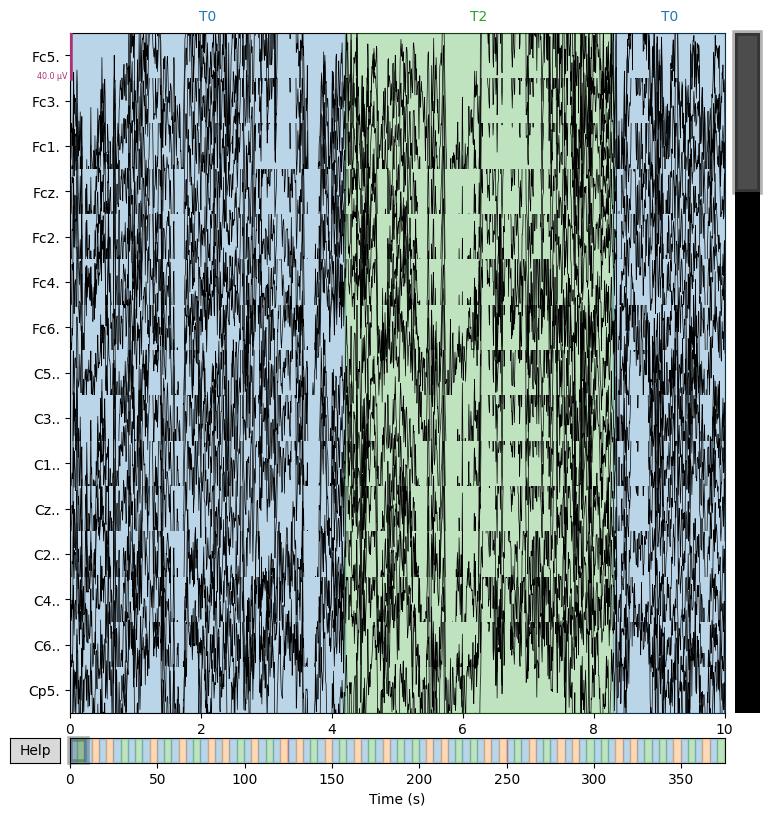

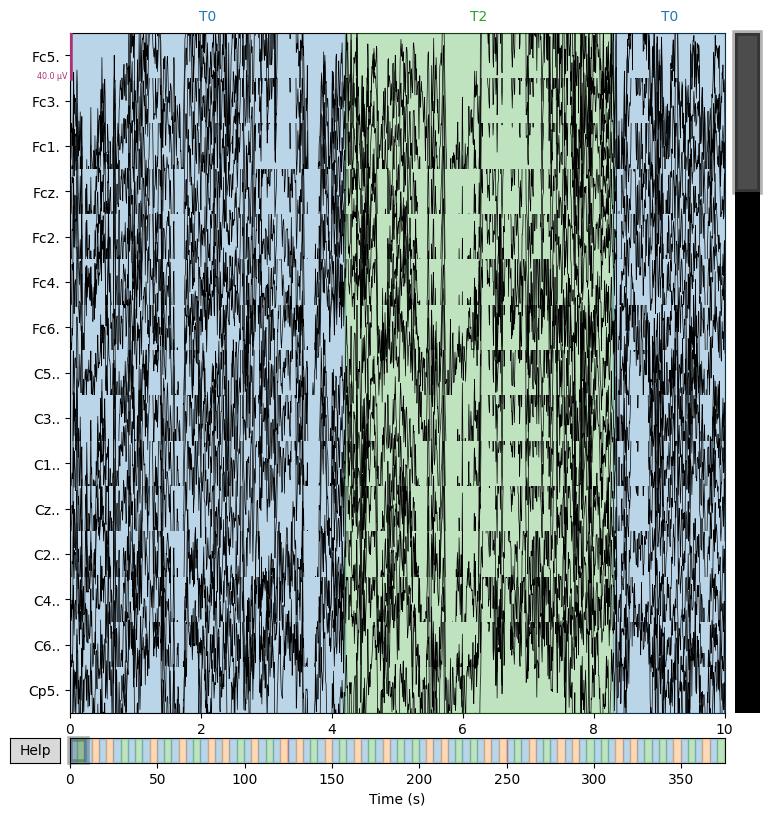

In [4]:
%matplotlib inline
raw.plot(duration=10, n_channels=15)

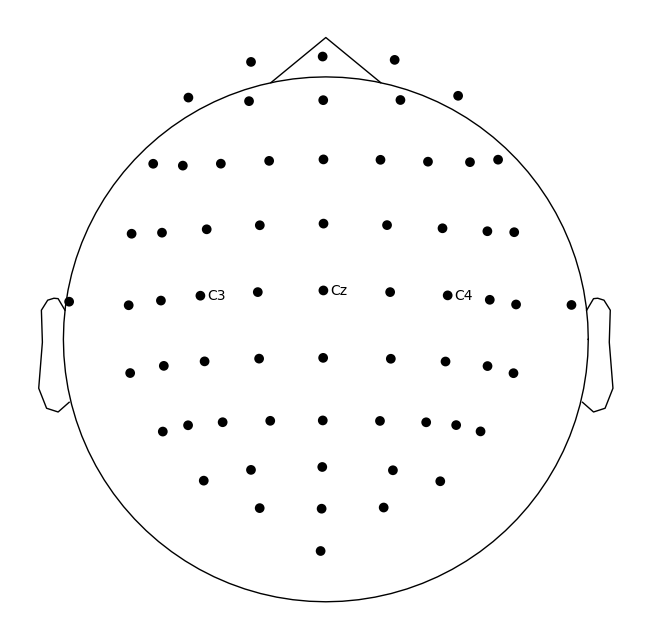

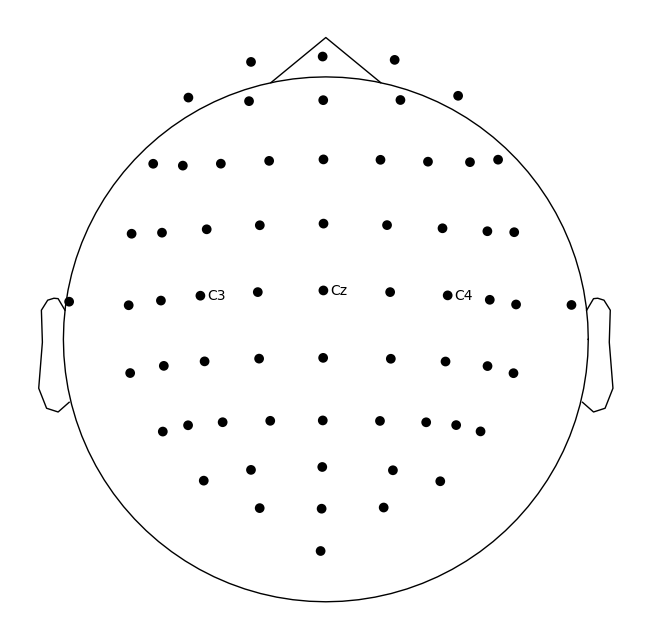

In [5]:
from mne.channels import make_standard_montage
from mne.datasets import eegbci

# clean the dotted names: 'C3..' -> 'C3', 'Cz..' -> 'Cz', etc.
eegbci.standardize(raw)

# attach real electrode positions (the layout from the scalp map)
montage = make_standard_montage('standard_1005')
raw.set_montage(montage)

# draw the sensor layout, labeling our three key electrodes
raw.plot_sensors(show_names=['C3', 'Cz', 'C4'])

In [6]:
raw.filter(8., 30., fir_design='firwin', skip_by_annotation='edge')

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MB, data loaded>

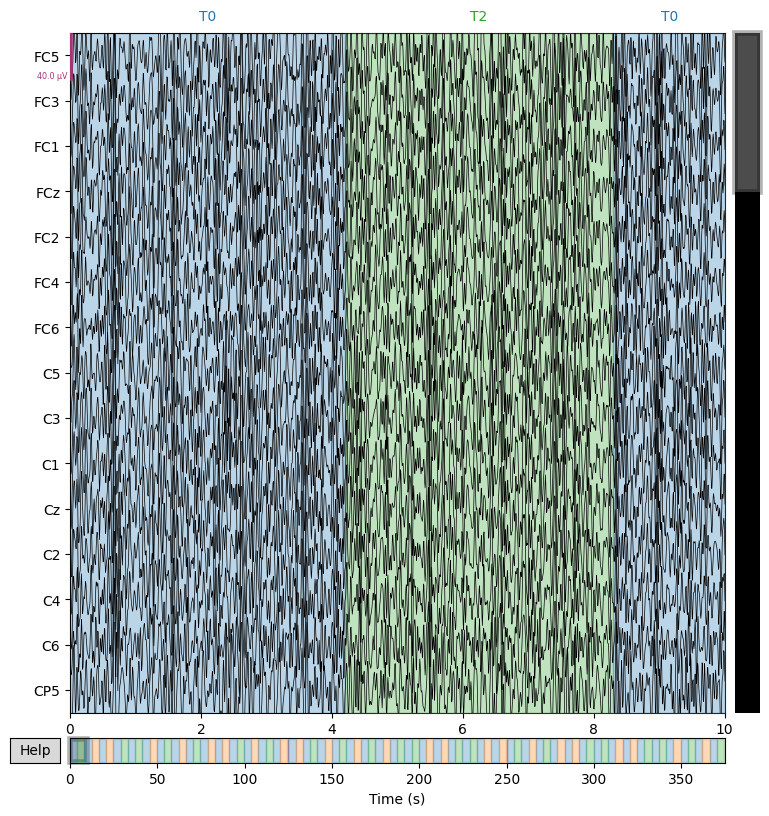

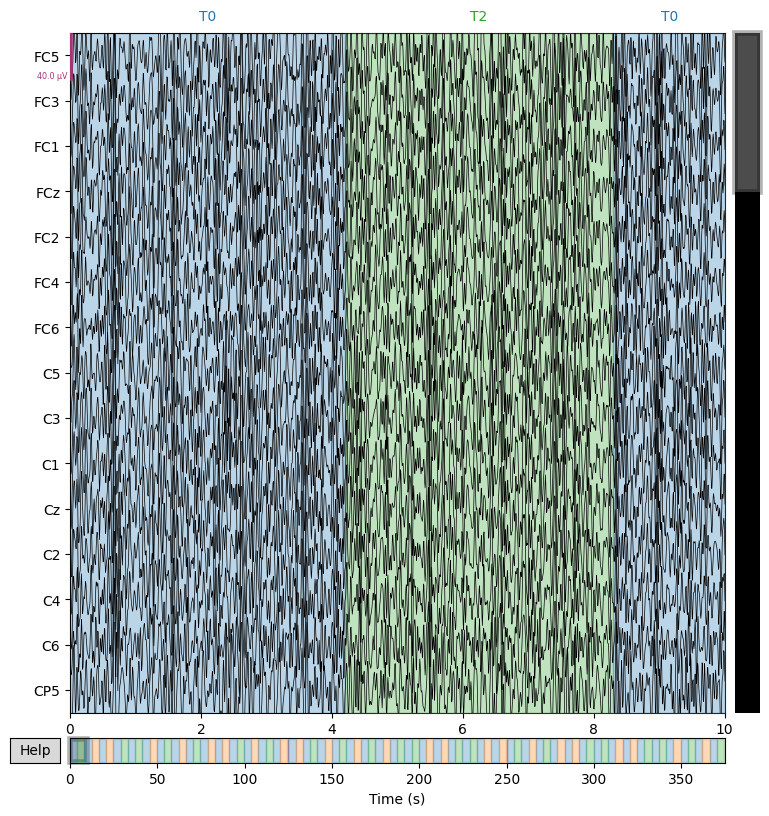

In [7]:
raw.plot(duration=10, n_channels=15)

In [8]:
import mne

# 1. turn the T1/T2 text markers into a numeric event list
events, event_id = mne.events_from_annotations(raw)
print("What MNE found:", event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
What MNE found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [9]:
# window: start 0.5s after the cue, end 2.5s after (a 2-second slice)
#first half-second after the cue is contaminated by that automatic startle response, so we skip it 
#The back edge is unreliable too. By three or four seconds in, people's imagery gets sloppy.

#so the middle 2 second slice is the cleaner part of the trial
tmin, tmax = 0.5, 2.5 

# grab only the two imagery classes; ignore rest (T0)
picks = {'left': 2, 'right': 3}

epochs = mne.Epochs(
    raw, events, event_id=picks,
    tmin=tmin, tmax=tmax,
    baseline=None, #review this choice
    picks='eeg',
    preload=True,
)

print(epochs)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 321 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MB, data loaded,
 'left': 23
 'right': 22>


In [10]:
X = epochs.get_data()          # the trial data
y = epochs.events[:, -1]       # the label for each trial

print("X shape:", X.shape)
print("y shape:", y.shape)
print("labels in y:", set(y))

X shape: (45, 64, 321)
y shape: (45,)
labels in y: {np.int64(2), np.int64(3)}


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

# hold back 30% to test on; stratify keeps the left/right balance even
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# build the decoder: CSP finds the electrode mixes, LDA draws the line
csp = CSP(n_components=4)
lda = LinearDiscriminantAnalysis()
decoder = Pipeline([('csp', csp), ('lda', lda)])

# learn from training trials only
decoder.fit(X_train, y_train)

# score on trials it has never seen
accuracy = decoder.score(X_test, y_test)
print(f"Accuracy on held-out trials: {accuracy:.1%}")

Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Accuracy on held-out trials: 71.4%


/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: divide by zero encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: overflow encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: invalid value encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: divide by zero encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: overflow encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv

In [13]:
#cross validation 

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

# regularized CSP: 'ledoit_wolf' steadies the math when trials are few
csp = CSP(n_components=4, reg='ledoit_wolf')
lda = LinearDiscriminantAnalysis()
decoder = Pipeline([('csp', csp), ('lda', lda)])

# 5-fold cross-validation, keeping left/right balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(decoder, X, y, cv=cv)

print("Score each fold:", np.round(scores, 3))
print(f"Average accuracy: {scores.mean():.1%}")
print(f"Spread (std dev): {scores.std():.1%}")

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance u

/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: divide by zero encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: overflow encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: invalid value encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: divide by zero encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: overflow encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv

    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Score each fold: [0.444 0.889 0.889 1.    0.667]
Average accuracy: 77.8%
Spread (std dev): 19.9%


/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: divide by zero encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: overflow encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: invalid value encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: divide by zero encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:646: RuntimeWarning: overflow encountered in matmul
  eigen_vectors = sub_vec.T @ eigen_vectors
/Users/lucylu/bci-project/venv

In [ ]:
#channel reduction experiment w/ 9 electrodes

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

# electrodes over the motor cortex: a 3x3 grid around C3 / Cz / C4
motor_channels = ['FC3', 'FCz', 'FC4',
                  'C3',  'Cz',  'C4',
                  'CP3', 'CPz', 'CP4']

# reduce the trials to just those channels
epochs_motor = epochs.copy().pick(motor_channels)
X_motor = epochs_motor.get_data()
y = epochs_motor.events[:, -1]
print("Reduced data shape:", X_motor.shape)

# same decoder, same evaluation as before
csp = CSP(n_components=4, reg='ledoit_wolf')
lda = LinearDiscriminantAnalysis()
decoder = Pipeline([('csp', csp), ('lda', lda)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_motor = cross_val_score(decoder, X_motor, y, cv=cv)

print("Score each fold:", np.round(scores_motor, 3))
print(f"Average accuracy: {scores_motor.mean():.1%}")
print(f"Spread (std dev): {scores_motor.std():.1%}")

Reduced data shape: (45, 9, 321)
Computing rank from data with rank=None
    Using tolerance 1.1e-05 (2.2e-16 eps * 9 dim * 5.6e+09  max singular value)
    Estimated rank (data): 9
    data: rank 9 computed from 9 data channels with 0 projectors
Reducing data rank from 9 -> 9
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e-05 (2.2e-16 eps * 9 dim * 5.6e+09  max singular value)
    Estimated rank (data): 9
    data: rank 9 computed from 9 data channels with 0 projectors
Reducing data rank from 9 -> 9
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e-05 (2.2e-16 eps * 9 dim * 5.6e+09  max singular value)
    Estimated rank (data): 9
    data: rank 9 computed from 9 data channels with 0 projectors
Reducing data rank from 9 -> 9
Estimating class

/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: divide by zero encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: overflow encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: invalid value encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: divide by zero encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for cov in covs], float)
/Users/lucylu/bci-project/venv/lib/python3.9/site-packages/mne/decoding/csp.py:633: RuntimeWarning: overflow encountered in matmul
  covs = np.array([sub_vec @ cov @ sub_vec.T for

In [15]:
#electrode sweep experiment

import numpy as np
import warnings
import mne
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

mne.set_log_level('ERROR')   # quiet MNE's per-fit chatter so we can read results
y = epochs.events[:, -1]

# rank all 64 channels by distance from the motor cortex center
pos = epochs.get_montage().get_positions()['ch_pos']        # name -> 3D position
motor_center = np.mean([pos['C3'], pos['Cz'], pos['C4']], axis=0)
distances = {ch: np.linalg.norm(pos[ch] - motor_center) for ch in epochs.ch_names}
ranked_channels = sorted(epochs.ch_names, key=lambda ch: distances[ch])

# the channel counts we'll test
channel_counts = [3, 6, 9, 15, 24, 32, 48, 64]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for n in channel_counts:
    chans = ranked_channels[:n]                 # the n closest to motor cortex
    X_n = epochs.copy().pick(chans).get_data()

    decoder = Pipeline([
        ('csp', CSP(n_components=min(4, n), reg='ledoit_wolf')),
        ('lda', LinearDiscriminantAnalysis()),
    ])

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')          # hide the CSP math warnings
        scores = cross_val_score(decoder, X_n, y, cv=cv)

    results.append((n, scores.mean(), scores.std()))
    print(f"{n:>2} channels:  {scores.mean():.1%}  (spread {scores.std():.1%})")

results = np.array(results)


 3 channels:  60.0%  (spread 11.3%)
 6 channels:  55.6%  (spread 14.1%)
 9 channels:  75.6%  (spread 8.3%)
15 channels:  80.0%  (spread 16.3%)
24 channels:  75.6%  (spread 8.3%)
32 channels:  66.7%  (spread 7.0%)
48 channels:  75.6%  (spread 14.7%)
64 channels:  77.8%  (spread 19.9%)


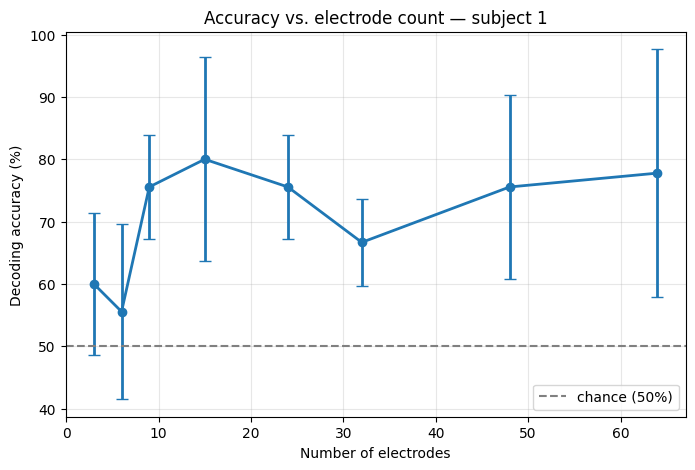

In [16]:
import matplotlib.pyplot as plt

counts, means, stds = results[:, 0], results[:, 1] * 100, results[:, 2] * 100

plt.figure(figsize=(8, 5))
plt.errorbar(counts, means, yerr=stds, marker='o', capsize=4, linewidth=2)
plt.axhline(50, linestyle='--', color='gray', label='chance (50%)')
plt.xlabel('Number of electrodes')
plt.ylabel('Decoding accuracy (%)')
plt.title('Accuracy vs. electrode count — subject 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# for testing on multi-subjects, build function and then loop over all subjects and use the function

import numpy as np
import mne
from mne.io import read_raw_edf, concatenate_raws
from mne.datasets import eegbci
from mne.channels import make_standard_montage

mne.set_log_level('ERROR')   # keep the loop quiet

def load_subject(subject):
    """Load one subject's left/right hand imagery, return clean X and y."""
    runs = [4, 8, 12]

    # load and combine the three imagery runs
    fnames = eegbci.load_data(subject, runs)
    raw = concatenate_raws([read_raw_edf(f, preload=True) for f in fnames])

    # fix channel names, attach positions, filter to the motor band
    eegbci.standardize(raw)
    raw.set_montage(make_standard_montage('standard_1005'))
    raw.filter(8., 30., fir_design='firwin', skip_by_annotation='edge')

    # slice into labeled trials
    events, event_id = mne.events_from_annotations(raw)
    picks = {'left': event_id['T1'], 'right': event_id['T2']}
    epochs = mne.Epochs(raw, events, event_id=picks,
                        tmin=0.5, tmax=2.5, baseline=None,
                        picks='eeg', preload=True)

    X = epochs.get_data()
    y = epochs.events[:, -1]
    return X, y, epochs

X, y, epochs = load_subject(1)
print("Subject 1:", X.shape, "labels:", set(y))

Subject 1: (45, 64, 321) labels: {np.int64(2), np.int64(3)}


In [21]:
import numpy as np
import warnings
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

subjects = range(1, 26)
channel_counts = [3, 6, 9, 15, 24, 32, 48, 64]
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=42)

all_results = {}   # subject -> list of accuracy per channel count

for subj in subjects:
    try: #try exception is for those subjects that have bad data and will cause function to crash
        X, y, epochs = load_subject(subj)

        # rank this subject's channels by distance from motor cortex
        pos = epochs.get_montage().get_positions()['ch_pos']
        center = np.mean([pos['C3'], pos['Cz'], pos['C4']], axis=0)
        ranked = sorted(epochs.ch_names, key=lambda ch: np.linalg.norm(pos[ch] - center))

        subj_scores = []
        for n in channel_counts:
            X_n = epochs.copy().pick(ranked[:n]).get_data()
            decoder = Pipeline([
                ('csp', CSP(n_components=min(4, n), reg='ledoit_wolf')),
                ('lda', LinearDiscriminantAnalysis()),
            ])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                scores = cross_val_score(decoder, X_n, y, cv=cv)
            subj_scores.append(scores.mean())

        all_results[subj] = subj_scores
        print(f"Subject {subj}: " + "  ".join(f"{s:.0%}" for s in subj_scores))

    except Exception as e: #print SKIPPED instead of crashing
        print(f"Subject {subj}: SKIPPED ({type(e).__name__})")

Subject 1: 56%  54%  71%  71%  72%  64%  69%  74%
Subject 2: 57%  67%  69%  78%  92%  94%  92%  90%
Subject 3: 50%  47%  50%  51%  44%  42%  44%  61%
Subject 4: 71%  61%  59%  51%  66%  54%  49%  51%


Subject 5: 45%  52%  71%  66%  54%  65%  64%  60%


Subject 6: 37%  48%  48%  40%  38%  45%  46%  42%


Subject 7: 78%  82%  86%  94%  95%  96%  97%  98%


Subject 8: 42%  44%  41%  47%  54%  54%  56%  59%


...

Failed to download 'S022R08.edf'. Will attempt the download again 2 more times.


Subject 22: 47%  43%  56%  53%  61%  63%  55%  63%


Subject 23: 55%  58%  53%  57%  52%  58%  59%  63%


Subject 24: 56%  53%  69%  54%  56%  48%  55%  48%


Subject 25: 64%  55%  56%  48%  55%  51%  45%  48%


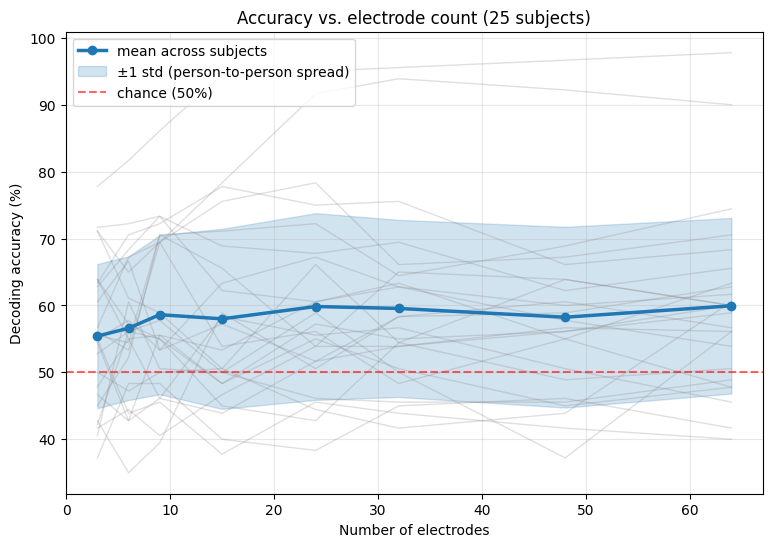

In [ ]:
#plot 
import numpy as np
import matplotlib.pyplot as plt

counts = np.array(channel_counts)
curves = np.array([all_results[s] for s in all_results]) * 100   # subjects x counts

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)

plt.figure(figsize=(9, 6))

# every subject's individual curve, faint
for row in curves:
    plt.plot(counts, row, color='gray', alpha=0.25, linewidth=1)

# the average curve, bold, with the spread band
plt.plot(counts, mean_curve, color='C0', linewidth=2.5, marker='o', label='mean across subjects')
plt.fill_between(counts, mean_curve - std_curve, mean_curve + std_curve,
                 color='C0', alpha=0.2, label='±1 std (person-to-person spread)')

plt.axhline(50, linestyle='--', color='red', alpha=0.6, label='chance (50%)')
plt.xlabel('Number of electrodes')
plt.ylabel('Decoding accuracy (%)')
plt.title(f'Accuracy vs. electrode count ({len(all_results)} subjects)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
#save raw results
import json

with open('results_25subjects.json', 'w') as f:
    json.dump(all_results, f)

print("Saved to results_25subjects.json")

Saved to results_25subjects.json


In [24]:
import json

with open('results_25subjects.json', 'r') as f:
    loaded = json.load(f)

# JSON stores dictionary keys as text, so convert them back to integers
loaded = {int(k): v for k, v in loaded.items()}

print(f"Loaded {len(loaded)} subjects")
print("Subject 7:", [f"{s:.0%}" for s in loaded[7]])

Loaded 25 subjects
Subject 7: ['78%', '82%', '86%', '94%', '95%', '96%', '97%', '98%']


In [25]:
import numpy as np
import warnings
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

subjects = range(1, 110)
channel_counts = [3, 6, 9, 15, 24, 32, 48, 64]
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=42)

all_results = {}   # subject -> list of accuracy per channel count

for subj in subjects:
    try: #try exception is for those subjects that have bad data and will cause function to crash
        X, y, epochs = load_subject(subj)

        # rank this subject's channels by distance from motor cortex
        pos = epochs.get_montage().get_positions()['ch_pos']
        center = np.mean([pos['C3'], pos['Cz'], pos['C4']], axis=0)
        ranked = sorted(epochs.ch_names, key=lambda ch: np.linalg.norm(pos[ch] - center))

        subj_scores = []
        for n in channel_counts:
            X_n = epochs.copy().pick(ranked[:n]).get_data()
            decoder = Pipeline([
                ('csp', CSP(n_components=min(4, n), reg='ledoit_wolf')),
                ('lda', LinearDiscriminantAnalysis()),
            ])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                scores = cross_val_score(decoder, X_n, y, cv=cv)
            subj_scores.append(scores.mean())

        all_results[subj] = subj_scores
        print(f"Subject {subj}: " + "  ".join(f"{s:.0%}" for s in subj_scores))

    except Exception as e: #print SKIPPED instead of crashing
        print(f"Subject {subj}: SKIPPED ({type(e).__name__})")

Subject 1: 56%  54%  71%  71%  72%  64%  69%  74%
Subject 2: 57%  67%  69%  78%  92%  94%  92%  90%
Subject 3: 50%  47%  50%  51%  44%  42%  44%  61%
Subject 4: 71%  61%  59%  51%  66%  54%  49%  51%
Subject 5: 45%  52%  71%  66%  54%  65%  64%  60%
Subject 6: 37%  48%  48%  40%  38%  45%  46%  42%
Subject 7: 78%  82%  86%  94%  95%  96%  97%  98%
Subject 8: 42%  44%  41%  47%  54%  54%  56%  59%
Subject 9: 48%  55%  46%  58%  56%  57%  51%  46%
Subject 10: 61%  67%  53%  63%  67%  63%  58%  54%
Subject 11: 42%  56%  55%  45%  43%  54%  64%  60%
Subject 12: 53%  56%  58%  50%  59%  50%  37%  56%
Subject 13: 72%  72%  73%  69%  68%  69%  62%  66%
Subject 14: 54%  43%  46%  44%  52%  54%  57%  56%
Subject 15: 71%  65%  69%  76%  78%  66%  67%  71%
Subject 16: 64%  57%  55%  48%  57%  55%  56%  60%
Subject 17: 43%  35%  39%  59%  51%  58%  61%  57%
Subject 18: 41%  61%  51%  50%  46%  46%  46%  49%
Subject 19: 63%  71%  72%  78%  75%  76%  66%  68%
Subject 20: 55%  44%  46%  38%  46%  44%

Subject 25: 64%  55%  56%  48%  55%  51%  45%  48%


Subject 26: 46%  51%  75%  76%  74%  77%  78%  77%


Subject 27: 51%  52%  53%  52%  48%  50%  52%  50%


Subject 28: 58%  51%  43%  44%  48%  47%  46%  44%


...

Subject 105: 51%  63%  61%  65%  67%  65%  57%  49%


Subject 106: 48%  56%  43%  39%  50%  47%  37%  37%


Subject 107: 42%  44%  48%  47%  46%  41%  39%  40%


Subject 108: 70%  82%  78%  79%  78%  78%  79%  81%


Subject 109: 41%  53%  49%  52%  49%  38%  37%  34%


In [ ]:
print(f"{len(all_results)} subjects loaded successfully")


#save full run
import json

with open('results_109subjects.json', 'w') as f:
    json.dump(all_results, f)

print(f"Saved {len(all_results)} subjects to results_109subjects.json")

109 subjects loaded successfully
Saved 109 subjects to results_109subjects.json


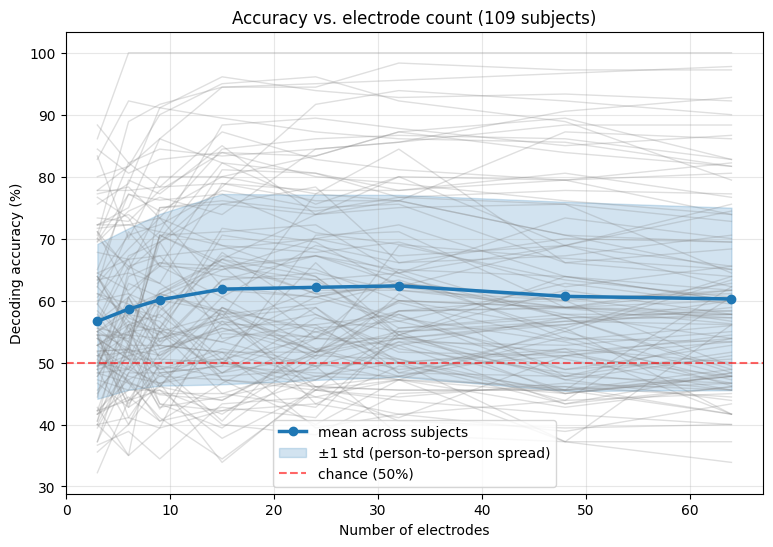

<Figure size 640x480 with 0 Axes>

In [8]:
#plot
import numpy as np
import matplotlib.pyplot as plt

counts = np.array(channel_counts)
curves = np.array([all_results[s] for s in all_results]) * 100   # subjects x counts

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)

plt.figure(figsize=(9, 6))

# every subject's individual curve, faint
for row in curves:
    plt.plot(counts, row, color='gray', alpha=0.25, linewidth=1)

# the average curve, bold, with the spread band
plt.plot(counts, mean_curve, color='C0', linewidth=2.5, marker='o', label='mean across subjects')
plt.fill_between(counts, mean_curve - std_curve, mean_curve + std_curve,
                 color='C0', alpha=0.2, label='±1 std (person-to-person spread)')

plt.axhline(50, linestyle='--', color='red', alpha=0.6, label='chance (50%)')
plt.xlabel('Number of electrodes')
plt.ylabel('Decoding accuracy (%)')
plt.title(f'Accuracy vs. electrode count ({len(all_results)} subjects)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.savefig('accuracy_vs_channels.png', dpi=150, bbox_inches='tight')

Findings summary:

Decoding accuracy plateaus at around 9 to 15 electrodes; beyond that, additional electrodes give no meaningful improvement, confirming that a small motor-cortex electrode set decodes motor imagery about as well as the full 64-channel cap. But this channel-count effect is small (roughly 5 points) compared to the person-to-person variation (roughly 40+ points), meaning the dominant factor in motor-imagery decoding is the individual, not the number of electrodes. A substantial fraction of subjects performed at or below chance regardless of electrode count, consistent with the known BCI-illiteracy phenomenon.


In [9]:
import numpy as np

counts = np.array(channel_counts)
curves = np.array([all_results[s] for s in sorted(all_results)]) * 100

mean_curve = curves.mean(axis=0)
std_curve = curves.std(axis=0)

# best channel count per subject
best_counts = [channel_counts[np.argmax(all_results[s])] for s in all_results]

print("Channels :", counts)
print("Mean acc :", np.round(mean_curve, 1))
print("Std (spread):", np.round(std_curve, 1))
print()
print(f"Peak of mean curve: {mean_curve.max():.1f}% at {counts[mean_curve.argmax()]} electrodes")
print(f"Accuracy at  9 ch: {mean_curve[channel_counts.index(9)]:.1f}%")
print(f"Accuracy at 64 ch: {mean_curve[channel_counts.index(64)]:.1f}%")
print()
# how many subjects are basically at chance (best score under 60%)
weak = sum(1 for s in all_results if max(all_results[s]) < 0.60)
print(f"Subjects whose best score never reached 60%: {weak} of {len(all_results)}")
print(f"Best-electrode-count varied per subject: min {min(best_counts)}, max {max(best_counts)}")

Channels : [ 3  6  9 15 24 32 48 64]
Mean acc : [56.6 58.6 60.1 61.8 62.1 62.4 60.7 60.3]
Std (spread): [12.5 13.  13.9 15.4 14.9 14.7 15.3 14.7]

Peak of mean curve: 62.4% at 32 electrodes
Accuracy at  9 ch: 60.1%
Accuracy at 64 ch: 60.3%

Subjects whose best score never reached 60%: 34 of 109
Best-electrode-count varied per subject: min 3, max 64


In [10]:
import numpy as np

# each subject's best accuracy across channel counts
best_per_subject = np.array([max(all_results[s]) for s in all_results]) * 100

print(f"Lowest subject's best score:  {best_per_subject.min():.1f}%")
print(f"Highest subject's best score: {best_per_subject.max():.1f}%")
print(f"Range: {best_per_subject.max() - best_per_subject.min():.1f} points")
print(f"Standard deviation of best scores: {best_per_subject.std():.1f} points")

Lowest subject's best score:  47.8%
Highest subject's best score: 100.0%
Range: 52.2 points
Standard deviation of best scores: 13.0 points


Summary of findings (quant)

Across 109 subjects, individual best-case decoding accuracy ranged from 47.8% (chance level) to 100%, a 52-point spread, while changing the electrode count moved the average by only about 2 points. The person matters roughly 25 times more than the hardware.

Individual matters far more than the hardware. 31% of subjects never exceeded 60% accuracy at any electrode count, consistent with documented BCI illiteracy.
